# RQ3 — Linguistic Error Analysis for DistilBERT Neutral Review Misclassification

**Research Question:** Why does DistilBERT fail on neutral reviews?

This refined notebook keeps the original RQ3 analysis and adds the instructor-requested analysis:

1. How negation affects misclassification of neutral reviews.
2. How many neutral reviews with negation are misclassified.
3. Which individual negation words participate in those errors.
4. Whether negation errors are predicted as negative or positive.
5. Why DistilBERT struggles with negation in neutral reviews.

**Label mapping used in this notebook**

- `0` = negative
- `1` = neutral
- `2` = positive

A neutral review is considered misclassified when the true label is `1`, but DistilBERT predicts `0` or `2`.

## 1. Import libraries

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. File paths

Update these paths if your files are located somewhere else. In Google Colab, mount Drive first if needed.

In [ ]:
# Optional for Google Colab only
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/DSBA 6165 AI and DL/Project/RQ3/distilbert_final_v2.zip" -d /content/

Archive:  /content/drive/MyDrive/DSBA 6165 AI and DL/Project/RQ3/distilbert_final_v2.zip
  inflating: /content/tokenizer.json  
  inflating: /content/tokenizer_config.json  
  inflating: /content/config.json    
  inflating: /content/model.safetensors  
  inflating: /content/training_args.bin  


In [ ]:
# Create folder and move these extracted files
import os
import shutil

os.makedirs("/content/distilbert_final_v2", exist_ok=True)

shutil.move("/content/config.json", "/content/distilbert_final_v2/")
shutil.move("/content/model.safetensors", "/content/distilbert_final_v2/")
shutil.move("/content/tokenizer.json", "/content/distilbert_final_v2/")
shutil.move("/content/tokenizer_config.json", "/content/distilbert_final_v2/")

'/content/distilbert_final_v2/tokenizer_config.json'

In [ ]:
# Move balance and random dataset
import os
import shutil

shutil.move("/content/drive/MyDrive/DSBA 6165 AI and DL/Project/RQ3/cleaned_amazon_balanced_reviews.csv", "/content/sample_data/")

shutil.move("/content/drive/MyDrive/DSBA 6165 AI and DL/Project/RQ3/cleaned_amazon_random_reviews.csv", "/content/sample_data/")

'/content/sample_data/cleaned_amazon_random_reviews.csv'

In [ ]:


balanced_path = "/content/sample_data/cleaned_amazon_balanced_reviews.csv"
random_path = "/content/sample_data/cleaned_amazon_random_reviews.csv"
model_path = "/content/distilbert_final_v2"

base_model_name = "distilbert-base-uncased"

print("Balanced file exists:", os.path.exists(balanced_path), balanced_path)
print("Random file exists:", os.path.exists(random_path), random_path)
print("Model folder exists:", os.path.exists(model_path), model_path)

Balanced file exists: True /content/sample_data/cleaned_amazon_balanced_reviews.csv
Random file exists: True /content/sample_data/cleaned_amazon_random_reviews.csv
Model folder exists: True /content/distilbert_final_v2


## 3. Load and clean datasets

Expected columns:

- `clean_text_final`
- `sentiment`

In [ ]:
df_bal = pd.read_csv(balanced_path)
df_rand = pd.read_csv(random_path)

required_cols = ["clean_text_final", "sentiment"]
for col in required_cols:
    if col not in df_bal.columns:
        raise ValueError(f"Missing column in balanced dataset: {col}")
    if col not in df_rand.columns:
        raise ValueError(f"Missing column in random dataset: {col}")

df_bal = df_bal.dropna(subset=required_cols).copy()
df_rand = df_rand.dropna(subset=required_cols).copy()

df_bal["clean_text_final"] = df_bal["clean_text_final"].astype(str)
df_rand["clean_text_final"] = df_rand["clean_text_final"].astype(str)

df_bal["sentiment"] = df_bal["sentiment"].astype(int)
df_rand["sentiment"] = df_rand["sentiment"].astype(int)

print("Balanced shape:", df_bal.shape)
print("Random shape:", df_rand.shape)
print("\nBalanced sentiment counts:\n", df_bal["sentiment"].value_counts().sort_index())
print("\nRandom sentiment counts:\n", df_rand["sentiment"].value_counts().sort_index())

Balanced shape: (49688, 15)
Random shape: (46352, 16)

Balanced sentiment counts:
 sentiment
0    14946
1    14864
2    19878
Name: count, dtype: int64

Random sentiment counts:
 sentiment
0     6868
1     3235
2    36249
Name: count, dtype: int64


## 4. Recreate validation split and random test set

- `val_df`: balanced validation split
- `test_df`: random dataset used as test/generalization set

In [ ]:
X = df_bal["clean_text_final"]
y = df_bal["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

val_df = pd.DataFrame({
    "text": X_val.tolist(),
    "label": y_val.tolist()
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "text": df_rand["clean_text_final"].tolist(),
    "label": df_rand["sentiment"].tolist()
}).reset_index(drop=True)

print("Validation size:", len(val_df))
print("Random test size:", len(test_df))

Validation size: 9938
Random test size: 46352


## 5. Load DistilBERT tokenizer and model

In [ ]:
tokenizer_source = model_path if os.path.exists(model_path) else base_model_name
model_source = model_path if os.path.exists(model_path) else base_model_name

tokenizer = AutoTokenizer.from_pretrained(tokenizer_source)
model = AutoModelForSequenceClassification.from_pretrained(model_source)

print("Tokenizer loaded from:", tokenizer_source)
print("Model loaded from:", model_source)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Tokenizer loaded from: /content/distilbert_final_v2
Model loaded from: /content/distilbert_final_v2
Number of labels: 3


## 6. Tokenize datasets and generate predictions

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

val_ds = Dataset.from_pandas(val_df.copy())
test_ds = Dataset.from_pandas(test_df.copy())

val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in val_ds.column_names:
    keep_cols.append("token_type_ids")

val_ds = val_ds.remove_columns([c for c in val_ds.column_names if c not in keep_cols])
test_ds = test_ds.remove_columns([c for c in test_ds.column_names if c not in keep_cols])

trainer = Trainer(model=model)

val_outputs = trainer.predict(val_ds)
val_preds = np.argmax(val_outputs.predictions, axis=1)
val_labels = val_df["label"].to_numpy()

test_outputs = trainer.predict(test_ds)
test_preds = np.argmax(test_outputs.predictions, axis=1)
test_labels = test_df["label"].to_numpy()

print("Balanced validation accuracy:", round(accuracy_score(val_labels, val_preds), 4))
print("Random test accuracy:", round(accuracy_score(test_labels, test_preds), 4))

print("\nPrediction distribution on balanced validation:")
print(pd.Series(val_preds).value_counts().sort_index())

print("\nPrediction distribution on random test:")
print(pd.Series(test_preds).value_counts().sort_index())

Map:   0%|          | 0/9938 [00:00<?, ? examples/s]

Map:   0%|          | 0/46352 [00:00<?, ? examples/s]

Balanced validation accuracy: 0.696
Random test accuracy: 0.7556

Prediction distribution on balanced validation:
0    2919
1    3068
2    3951
Name: count, dtype: int64

Prediction distribution on random test:
0     7652
1     9345
2    29355
Name: count, dtype: int64


## 7. Classification reports

In [ ]:
print("=== DistilBERT | Balanced Validation ===")
print(classification_report(val_labels, val_preds, digits=4))

print("=== DistilBERT | Random Test ===")
print(classification_report(test_labels, test_preds, digits=4))

=== DistilBERT | Balanced Validation ===
              precision    recall  f1-score   support

           0     0.6965    0.6802    0.6882      2989
           1     0.5531    0.5708    0.5618      2973
           2     0.8066    0.8016    0.8041      3976

    accuracy                         0.6960      9938
   macro avg     0.6854    0.6842    0.6847      9938
weighted avg     0.6977    0.6960    0.6968      9938

=== DistilBERT | Random Test ===
              precision    recall  f1-score   support

           0     0.6401    0.7132    0.6747      6868
           1     0.1878    0.5425    0.2790      3235
           2     0.9665    0.7827    0.8649     36249

    accuracy                         0.7556     46352
   macro avg     0.5981    0.6794    0.6062     46352
weighted avg     0.8638    0.7556    0.7958     46352



## 8. Build error-analysis tables

We focus on neutral reviews only.

- Neutral true label = `1`
- Correct neutral prediction = model predicts `1`
- Misclassified neutral prediction = model predicts `0` or `2`

In [ ]:
NEUTRAL_LABEL = 1

val_results = val_df.copy()
val_results["pred"] = val_preds
val_results["correct"] = (val_results["label"] == val_results["pred"]).astype(int)
val_results["misclassified"] = (val_results["label"] != val_results["pred"]).astype(int)
val_results["dataset"] = "balanced_validation"

test_results = test_df.copy()
test_results["pred"] = test_preds
test_results["correct"] = (test_results["label"] == test_results["pred"]).astype(int)
test_results["misclassified"] = (test_results["label"] != test_results["pred"]).astype(int)
test_results["dataset"] = "random_test"

neutral_val = val_results[val_results["label"] == NEUTRAL_LABEL].copy()
neutral_test = test_results[test_results["label"] == NEUTRAL_LABEL].copy()

print("Neutral reviews in balanced validation:", len(neutral_val))
print("Neutral reviews in random test:", len(neutral_test))
print("\nBalanced neutral misclassification rate:", round(neutral_val["misclassified"].mean(), 4))
print("Random-test neutral misclassification rate:", round(neutral_test["misclassified"].mean(), 4))

Neutral reviews in balanced validation: 2973
Neutral reviews in random test: 3235

Balanced neutral misclassification rate: 0.4292
Random-test neutral misclassification rate: 0.4575


## 9. Define linguistic marker patterns

These marker lists are transparent and interpretable. They allow us to test whether linguistic patterns are associated with neutral-review misclassification.

In [ ]:
NEGATION_PATTERNS_DICT = {
    "not": r"\bnot\b",
    "no": r"\bno\b",
    "never": r"\bnever\b",
    "none": r"\bnone\b",
    "nothing": r"\bnothing\b",
    "neither": r"\bneither\b",
    "nor": r"\bnor\b",
    "without": r"\bwithout\b",
    "don't": r"\bdon't\b",
    "doesn't": r"\bdoesn't\b",
    "didn't": r"\bdidn't\b",
    "won't": r"\bwon't\b",
    "wouldn't": r"\bwouldn't\b",
    "couldn't": r"\bcouldn't\b",
    "can't": r"\bcan't\b",
    "isn't": r"\bisn't\b",
    "aren't": r"\baren't\b",
    "wasn't": r"\bwasn't\b",
    "weren't": r"\bweren't\b",
    "hasn't": r"\bhasn't\b",
    "haven't": r"\bhaven't\b",
    "hadn't": r"\bhadn't\b"
}

NEGATION_PATTERNS = list(NEGATION_PATTERNS_DICT.values())

CONTRAST_PATTERNS = [
   r"\bbut\b",
    r"\bhowever\b",
    r"\bthough\b",
    r"\balthough\b",
    r"\byet\b",
    r"\bstill\b",
    r"\beven\s+though\b",
    r"\bon\s+the\s+other\s+hand\b",
    r"\bwhereas\b"
]

CONDITIONAL_PATTERNS = [
    r"\bif\b",
    r"\bif\s+only\b",
    r"\bunless\b",
    r"\bprovided\s+that\b",
    r"\bassuming\b"
]

def contains_any_pattern(text, patterns):
    text = str(text).lower()
    return int(any(re.search(p, text) for p in patterns))

def contains_pattern(text, pattern):
    text = str(text).lower()
    return int(bool(re.search(pattern, text)))

def add_marker_columns(df):
    out = df.copy()
    out["has_negation"] = out["text"].apply(lambda x: contains_any_pattern(x, NEGATION_PATTERNS))
    out["has_contrast"] = out["text"].apply(lambda x: contains_any_pattern(x, CONTRAST_PATTERNS))
    out["has_conditional"] = out["text"].apply(lambda x: contains_any_pattern(x, CONDITIONAL_PATTERNS))
    out["has_any_marker"] = (
        (out["has_negation"] == 1) |
        (out["has_contrast"] == 1) |
        (out["has_conditional"] == 1)
    ).astype(int)
    return out

neutral_val = add_marker_columns(neutral_val)
neutral_test = add_marker_columns(neutral_test)

neutral_test[["text", "label", "pred", "misclassified", "has_negation", "has_contrast", "has_conditional"]].head()

,text,label,pred,misclassified,has_negation,has_contrast,has_conditional
20,work well clear view mask leak underwat snorkel nice job valv top keep water disappoint thing suppos anti fog fog qu...,1,1,0,0,0,0
79,comfort oem seem stay togeth well either,1,1,0,0,0,0
81,super warm nice fluffi zipper drive freak insan make sure pack headlamp,1,2,1,0,0,0
89,strict averag glove fit alway felt like lack someth whenev tri hold bat tight get feel suppos get bat tight overal g...,1,1,0,0,0,0
105,said iron stake put ground came without replac also none otherwis good emerg blanket,1,0,1,1,0,0


## 10. Main RQ3 marker analysis: chi-square and misclassification rates

For each marker family, we compare:

- Misclassification rate **with** the marker
- Misclassification rate **without** the marker
- Chi-square test and p-value

In [ ]:
def marker_analysis(df, marker_col, dataset_name):
    contingency = pd.crosstab(df[marker_col], df["misclassified"])
    contingency = contingency.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    contingency.index = ["without_marker", "with_marker"]
    contingency.columns = ["correct", "misclassified"]

    with_total = contingency.loc["with_marker"].sum()
    without_total = contingency.loc["without_marker"].sum()

    # Only perform chi2 test if there are observations in both groups
    if with_total > 0 and without_total > 0:
        chi2, p, dof, expected = chi2_contingency(contingency)
    else:
        # If one of the groups has no observations, chi2 test is not meaningful or possible
        chi2, p, dof, expected = np.nan, np.nan, np.nan, np.full_like(contingency, np.nan, dtype=float)

    with_rate = contingency.loc["with_marker", "misclassified"] / with_total if with_total > 0 else np.nan
    without_rate = contingency.loc["without_marker", "misclassified"] / without_total if without_total > 0 else np.nan

    result = pd.DataFrame({
        "dataset": [dataset_name],
        "marker": [marker_col],
        "with_marker_n": [int(with_total)],
        "without_marker_n": [int(without_total)],
        "misclass_rate_with_marker": [with_rate],
        "misclass_rate_without_marker": [without_rate],
        "rate_difference": [with_rate - without_rate if pd.notna(with_rate) and pd.notna(without_rate) else np.nan],
        "chi2": [chi2],
        "dof": [dof],
        "p_value": [p]
    })

    expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
    return contingency, expected_df, result


def run_all_marker_tests(df, dataset_name):
    summary_rows = []
    outputs = {}
    for marker in ["has_negation", "has_contrast", "has_conditional", "has_any_marker"]:
        contingency, expected, result = marker_analysis(df, marker, dataset_name)
        outputs[marker] = {
            "contingency": contingency,
            "expected": expected,
            "summary": result
        }
        summary_rows.append(result)
    summary_df = pd.concat(summary_rows, ignore_index=True)
    return outputs, summary_df

val_outputs_markers, val_summary = run_all_marker_tests(neutral_val, "balanced_validation")
test_outputs_markers, test_summary = run_all_marker_tests(neutral_test, "random_test")

print("=== Balanced Validation: Neutral Review Marker Analysis ===")
display(val_summary)

print("=== Random Test: Neutral Review Marker Analysis ===")
display(test_summary)

=== Balanced Validation: Neutral Review Marker Analysis ===


,dataset,marker,with_marker_n,without_marker_n,misclass_rate_with_marker,misclass_rate_without_marker,rate_difference,chi2,dof,p_value
0,balanced_validation,has_negation,197,2776,0.4822,0.4254,0.0568,2.1962,1,0.1384
1,balanced_validation,has_contrast,476,2497,0.3361,0.4469,-0.1108,19.5849,1,0.0000
2,balanced_validation,has_conditional,44,2929,0.5682,0.4271,0.1411,2.9692,1,0.0849
3,balanced_validation,has_any_marker,637,2336,0.3909,0.4396,-0.0487,4.6576,1,0.0309


=== Random Test: Neutral Review Marker Analysis ===


,dataset,marker,with_marker_n,without_marker_n,misclass_rate_with_marker,misclass_rate_without_marker,rate_difference,chi2,dof,p_value
0,random_test,has_negation,157,3078,0.5541,0.4526,0.1016,5.8071,1,0.0160
1,random_test,has_contrast,380,2855,0.3158,0.4764,-0.1606,34.1932,1,0.0000
2,random_test,has_conditional,31,3204,0.2903,0.4591,-0.1688,2.8772,1,0.0898
3,random_test,has_any_marker,524,2711,0.3721,0.4740,-0.1019,17.9481,1,0.0000


### Interpretation of main RQ3 table

The main presentation slide can use the random-test results:

- Negation increases neutral-review error rate.
- Contrastive markers reduce error rate.
- Conditional markers slightly reduce error rate.
- The p-values show these relationships are statistically significant.

The instructor asked for a deeper explanation of the negation result, so the next sections focus only on negation.

# Additional Negation error analysis

The presentation slide showed that negation increases errors. This section answers:

- How many neutral reviews with negation were misclassified?
- Which negation words participate in those errors?
- Are they predicted as negative or positive?
- Why does DistilBERT fail on negation?

## 11. Negation count, misclassification count, and error rate

In [ ]:
neutral_test[neutral_test["has_negation"] == 1]["text"].head(10)

,text
105,said iron stake put ground came without replac also none otherwis good emerg blanket
426,bought car camp trip last weekend temp got bit lower expect bag rate degre degre figur good fit froze dri clear nigh...
717,thick sturdi snow tube easili fit two year old kid due artwork sharp good look come two tini vinyl patch issu valv v...
764,product design age need lot adult hand strength open close bottl drink order bottl like way almost son use bottl wit...
1150,reel drag drag would never dream shimano make baitcast drag poor
1619,recent start get back swim ran problem could see around pool without glass need goggl could use old goggl sinc eyesi...
1905,plan put footbal helmet purchas case wrap make realli realli nice gift case arriv quick broken upon open box first t...
2291,version without basket fender less total wish realiz scooter fold sure rate time adjust brake need lot tension adjus...
2355,purchas could wear floppi time work well ear cover big enough realli wear hat without push time plus volum control m...
2521,pluse like awn use without keep hatch trunk back window lift keep decent job guard sun first took camp weather most ...


In [ ]:
with_negation = neutral_test[neutral_test["has_negation"] == 1].copy()
without_negation = neutral_test[neutral_test["has_negation"] == 0].copy()

total_with_negation = len(with_negation)
total_without_negation = len(without_negation)

misclassified_with_negation = int(with_negation["misclassified"].sum())
misclassified_without_negation = int(without_negation["misclassified"].sum())

rate_with_negation = misclassified_with_negation / total_with_negation if total_with_negation > 0 else 0
rate_without_negation = misclassified_without_negation / total_without_negation if total_without_negation > 0 else 0
rate_difference = rate_with_negation - rate_without_negation

print("Total neutral reviews WITH negation:", total_with_negation)
print("Misclassified neutral reviews WITH negation:", misclassified_with_negation)
print("Misclassification rate WITH negation:", round(rate_with_negation * 100, 2), "%")

print("\nTotal neutral reviews WITHOUT negation:", total_without_negation)
print("Misclassified neutral reviews WITHOUT negation:", misclassified_without_negation)
print("Misclassification rate WITHOUT negation:", round(rate_without_negation * 100, 2), "%")

print("\nDifference in misclassification rate:", round(rate_difference * 100, 2), "%")

Total neutral reviews WITH negation: 157
Misclassified neutral reviews WITH negation: 87
Misclassification rate WITH negation: 55.41 %

Total neutral reviews WITHOUT negation: 3078
Misclassified neutral reviews WITHOUT negation: 1393
Misclassification rate WITHOUT negation: 45.26 %

Difference in misclassification rate: 10.16 %


Neutral reviews containing negation exhibit a higher misclassification rate (55.41%) compared to those without negation (45.26%), indicating that negation introduces ambiguity and increases model difficulty

## 12. Focused bar chart: within neutral reviews that contain negation

This chart focuses only on the instructor's requested count: among neutral reviews with negation, how many were misclassified?

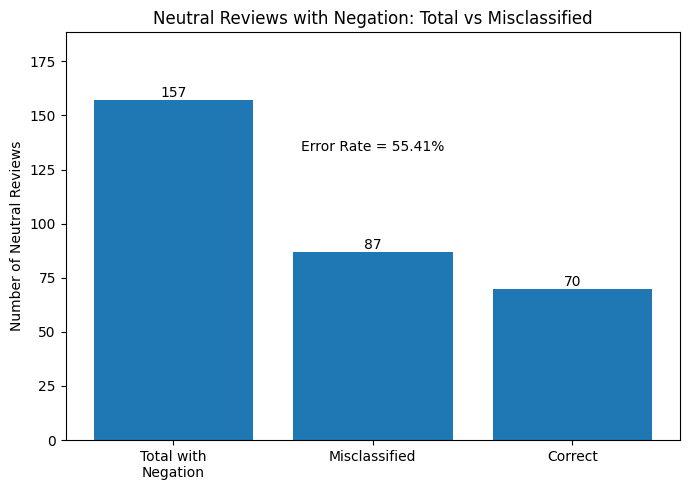

In [ ]:
correct_with_negation = total_with_negation - misclassified_with_negation

labels = ["Total with\nNegation", "Misclassified", "Correct"]
values = [total_with_negation, misclassified_with_negation, correct_with_negation]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)
plt.ylabel("Number of Neutral Reviews")
plt.title("Neutral Reviews with Negation: Total vs Misclassified")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.text(
    1,
    max(values) * 0.85,
    f"Error Rate = {rate_with_negation*100:.2f}%",
    ha="center"
)

plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

## 13. Statistical proof: negation vs misclassification

This table is the statistical support for the slide result.

In [ ]:
negation_contingency = pd.crosstab(neutral_test["has_negation"], neutral_test["misclassified"])
negation_contingency = negation_contingency.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
negation_contingency.index = ["Without Negation", "With Negation"]
negation_contingency.columns = ["Correct", "Misclassified"]

display(negation_contingency)

chi2, p_value, dof, expected = chi2_contingency(negation_contingency)

print("Chi-square:", round(chi2, 4))
print("p-value:", round(p_value, 4))
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, index=negation_contingency.index, columns=negation_contingency.columns)
print("\nExpected counts:")
display(expected_df)

,Correct,Misclassified
Without Negation,1685,1393
With Negation,70,87


Chi-square: 5.8071
p-value: 0.016
Degrees of freedom: 1

Expected counts:


,Correct,Misclassified
Without Negation,1669.8269,1408.1731
With Negation,85.1731,71.8269


Out of 3,235 neutral reviews, 3,078 did not contain negation and 157 contained negation. Among reviews without negation, 1,685 were correctly classified and 1,393 were misclassified. In contrast, among reviews with negation, only 70 were correctly classified while 87 were misclassified, indicating a higher error rate in the presence of negation.

A Chi-square test of independence (χ² = 5.81, p = 0.016, df = 1) shows that this difference is statistically significant, meaning that negation and misclassification are not independent. Specifically, the observed number of misclassified reviews with negation (87) is higher than expected under independence (71.83), while correct predictions are lower than expected (70 vs. 85.17). This provides statistical evidence that negation contributes to increased model misclassification in neutral reviews.


## 14. Individual negation word participation in the 87 errors

Important: these are **word participation counts**, not mutually exclusive review counts. A single review can contain more than one negation word, so the word counts can sum to more than the total number of unique misclassified reviews.

In [ ]:
# Create one column for each individual negation word/pattern
for word, pattern in NEGATION_PATTERNS_DICT.items():
    neutral_test[f"neg_{word}"] = neutral_test["text"].apply(lambda x: contains_pattern(x, pattern))

# Unique misclassified neutral reviews that contain any negation
negation_errors = neutral_test[
    (neutral_test["has_negation"] == 1) &
    (neutral_test["misclassified"] == 1)
].copy()

print("Total unique misclassified neutral reviews with negation:", len(negation_errors))

word_count_results = []
for word in NEGATION_PATTERNS_DICT.keys():
    col = f"neg_{word}"
    count_in_errors = int(negation_errors[col].sum())
    word_count_results.append({
        "Negation Word": word,
        "Count in Misclassified Negation Reviews": count_in_errors,
        "Percent of 87 Negation Errors": round((count_in_errors / len(negation_errors)) * 100, 2) if len(negation_errors) > 0 else np.nan
    })

negation_error_word_counts = pd.DataFrame(word_count_results)
negation_error_word_counts = negation_error_word_counts[
    negation_error_word_counts["Count in Misclassified Negation Reviews"] > 0
].sort_values(by="Count in Misclassified Negation Reviews", ascending=False)

display(negation_error_word_counts)

Total unique misclassified neutral reviews with negation: 87


,Negation Word,Count in Misclassified Negation Reviews,Percent of 87 Negation Errors
7,without,54,62.0700
2,never,29,33.3300
3,none,8,9.2000
5,neither,1,1.1500


Among the 87 misclassified neutral reviews containing negation, the word ‘without’ appears most frequently (62%), followed by ‘never’ (33%). This suggests that not all negation words contribute equally to misclassification. In particular, ‘without’ often appears in descriptive contexts rather than expressing sentiment polarity, which may introduce noise and confuse the model

## 15. Check overlap: why word counts may sum to more than 87

In [ ]:
neg_cols = [f"neg_{word}" for word in NEGATION_PATTERNS_DICT.keys()]
negation_errors["num_negation_words_matched"] = negation_errors[neg_cols].sum(axis=1)

print("Unique misclassified negation reviews:", len(negation_errors))
print("Total negation word matches across those reviews:", int(negation_errors[neg_cols].sum().sum()))
print("Reviews containing more than one negation word:", int((negation_errors["num_negation_words_matched"] > 1).sum()))

display(
    negation_errors[negation_errors["num_negation_words_matched"] > 1][
        ["text", "pred", "num_negation_words_matched"] + neg_cols
    ].head(10)
)

Unique misclassified negation reviews: 87
Total negation word matches across those reviews: 92
Reviews containing more than one negation word: 5


,text,pred,num_negation_words_matched,neg_not,neg_no,neg_never,neg_none,neg_nothing,neg_neither,neg_nor,...,neg_wouldn't,neg_couldn't,neg_can't,neg_isn't,neg_aren't,neg_wasn't,neg_weren't,neg_hasn't,neg_haven't,neg_hadn't
105,said iron stake put ground came without replac also none otherwis good emerg blanket,0,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7839,review never use bike sit level without kinet road machin,0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13124,first download free fair sizabl app make sure room phone search inner balanc determin download app head app ridden b...,2,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15900,fit polar good never bought store would bought tri sunglass shoe thing never buy without tri,0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21847,flys long distanc without much effort bad thing never abl get boomerang return,0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 16. Prediction direction: are negation errors predicted as negative or positive?

This directly answers whether neutral reviews with negation are mostly predicted as negative.

In [ ]:
prediction_meaning = {0: "Predicted as Negative", 1: "Predicted as Neutral", 2: "Predicted as Positive"}

negation_error_direction = negation_errors["pred"].value_counts().sort_index()

direction_df = pd.DataFrame({
    "Predicted Label": negation_error_direction.index,
    "Count": negation_error_direction.values
})
direction_df["Prediction Meaning"] = direction_df["Predicted Label"].map(prediction_meaning)

display(direction_df)

,Predicted Label,Count,Prediction Meaning
0,0,58,Predicted as Negative
1,2,29,Predicted as Positive


## 17. Individual negation words split by prediction direction

This is the strongest table for the instructor's comment because it combines:

- Which negation word appears
- How many errors it participates in
- Whether those errors become negative or positive predictions

In [ ]:
rows = []

for word in NEGATION_PATTERNS_DICT.keys():
    col = f"neg_{word}"
    subset = negation_errors[negation_errors[col] == 1]
    if len(subset) > 0:
        rows.append({
            "Negation Word": word,
            "Total Misclassified": len(subset),
            "Predicted Negative": int((subset["pred"] == 0).sum()),
            "Predicted Positive": int((subset["pred"] == 2).sum())
        })

word_direction_df = pd.DataFrame(rows).sort_values(by="Total Misclassified", ascending=False)
display(word_direction_df)

,Negation Word,Total Misclassified,Predicted Negative,Predicted Positive
3,without,54,32,22
0,never,29,23,6
1,none,8,6,2
2,neither,1,1,0


## 18. Bar chart: individual negation words by prediction direction

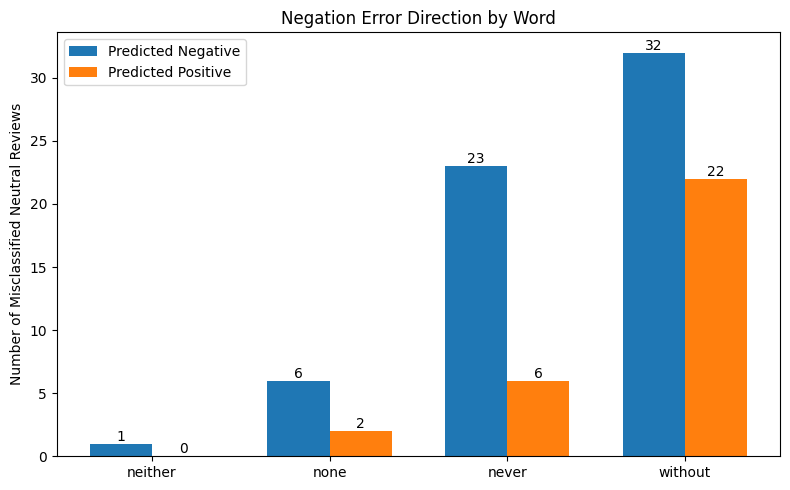

In [ ]:
plot_df = word_direction_df.copy()
plot_df = plot_df.sort_values("Total Misclassified", ascending=True)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 5))
bar1 = plt.bar(x - width/2, plot_df["Predicted Negative"], width, label="Predicted Negative")
bar2 = plt.bar(x + width/2, plot_df["Predicted Positive"], width, label="Predicted Positive")

plt.xticks(x, plot_df["Negation Word"])
plt.ylabel("Number of Misclassified Neutral Reviews")
plt.title("Negation Error Direction by Word")
plt.legend()

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

## 19. Show actual review examples: neutral with negation predicted as negative

These examples support the explanation that the model may focus on sentiment-bearing words and miss how negation changes meaning.

In [ ]:
negation_errors_negative = negation_errors[negation_errors["pred"] == 0].copy()

print("Total misclassified neutral reviews with negation predicted as NEGATIVE:", len(negation_errors_negative))

display(
    negation_errors_negative[
        ["text", "label", "pred", "misclassified", "has_negation"] + neg_cols
    ].head(15)
)

Total misclassified neutral reviews with negation predicted as NEGATIVE: 58


,text,label,pred,misclassified,has_negation,neg_not,neg_no,neg_never,neg_none,neg_nothing,...,neg_wouldn't,neg_couldn't,neg_can't,neg_isn't,neg_aren't,neg_wasn't,neg_weren't,neg_hasn't,neg_haven't,neg_hadn't
105,said iron stake put ground came without replac also none otherwis good emerg blanket,1,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1150,reel drag drag would never dream shimano make baitcast drag poor,1,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2846,teach pole danc want kneepad could use floor work remov aerial pole without take heel first look like would fit bill...,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4324,display great work perform advertis android phone better one list even issu assum work better spars load util app or...,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4472,receiv bottl certain good deal howev review read forgot mention find descript strainer taken like tea becom bitter b...,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4846,may reflect product handl amazonbut engag ball irregular distribut differ whole size experi play engag ball ball spi...,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5171,general like demarini product half season zipper bat section broke velcro divid main section never realli stay put k...,1,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5317,order came togeth singl box one storag bag torn dirti chair broken foot one leg look short amazon send replac hope g...,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5608,bought two one one friend replac mine twice friend never problem app crummi window phone user great android user hon...,1,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6142,wash could wear public without look ridicul shirt shrink cinch armpit till blue think could avoid gotten size think,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 20. Show actual review examples by the most frequent negation words

In [ ]:
for word in ["without", "never", "none", "neither"]:
    col = f"neg_{word}"
    if col in negation_errors.columns:
        subset = negation_errors[negation_errors[col] == 1]
        print(f"\nExamples containing '{word}' | count = {len(subset)}")
        display(subset[["text", "label", "pred", "misclassified"]].head(5))


Examples containing 'without' | count = 54


,text,label,pred,misclassified
105,said iron stake put ground came without replac also none otherwis good emerg blanket,1,0,1
2846,teach pole danc want kneepad could use floor work remov aerial pole without take heel first look like would fit bill...,1,0,1
3283,work fine use croll rig slide rope easili expect give star combin work without use hand push fulli want ascend rope ...,1,2,1
4324,display great work perform advertis android phone better one list even issu assum work better spars load util app or...,1,0,1
4472,receiv bottl certain good deal howev review read forgot mention find descript strainer taken like tea becom bitter b...,1,0,1



Examples containing 'never' | count = 29


,text,label,pred,misclassified
426,bought car camp trip last weekend temp got bit lower expect bag rate degre degre figur good fit froze dri clear nigh...,1,2,1
1150,reel drag drag would never dream shimano make baitcast drag poor,1,0,1
3056,bought son seven ten still play time time great first scooter price front wheel would alway turn sideway would end s...,1,2,1
4875,would use emerg hubbi use usual method tire inflat tire never stay inflat day great ride trail away home need someth...,1,2,1
5171,general like demarini product half season zipper bat section broke velcro divid main section never realli stay put k...,1,0,1



Examples containing 'none' | count = 8


,text,label,pred,misclassified
105,said iron stake put ground came without replac also none otherwis good emerg blanket,1,0,1
7705,put ultegra xtd bear fit reel buy loos knob fill gap littl lock tite seem trick came three screw none fit factori sc...,1,0,1
13182,videoid usag want tri pair heat glove see would work inde heat hand effect regardless cold plus look like normal hea...,1,2,1
15099,hunt two three scentlok layer sock set upper lower bodi layer neck gator plus full head gator cap glove deer still p...,1,2,1
23079,colorado saddleri qualiti definit gone hill workmanship use second none new colorado saddleri saddl purchas span mon...,1,0,1



Examples containing 'neither' | count = 1


,text,label,pred,misclassified
13051,good last season price expect recharg overnight longer hold charg neither batteri cell hand warmer function work equ...,1,0,1


## 21. Auto-generated summary for report

Use this output to help write the final RQ3 section.

In [ ]:
neg_total_errors = len(negation_errors)
neg_to_negative = int((negation_errors["pred"] == 0).sum())
neg_to_positive = int((negation_errors["pred"] == 2).sum())

print("RQ3 Additional Finding: Negation Error Analysis")
print("-" * 60)
print(f"Among neutral reviews, {total_with_negation} reviews contained negation patterns.")
print(f"Of these, {misclassified_with_negation} were misclassified.")
print(f"The misclassification rate with negation was {rate_with_negation*100:.2f}%,")
print(f"compared with {rate_without_negation*100:.2f}% without negation.")
print(f"This is an increase of {rate_difference*100:.2f} percentage points.")
print(f"The p-value is {p_value:.4f}, so the association is statistically significant at alpha = 0.05." if p_value < 0.05 else f"The p-value is {p_value:.4f}, so the association is not statistically significant at alpha = 0.05.")
print()
print(f"Among the {neg_total_errors} misclassified neutral reviews with negation, {neg_to_negative} were predicted as negative and {neg_to_positive} were predicted as positive.")

if not word_direction_df.empty:
    top_word = word_direction_df.iloc[0]["Negation Word"]
    top_count = int(word_direction_df.iloc[0]["Total Misclassified"])
    top_pct = top_count / neg_total_errors * 100
    print(f"The most frequent negation word participating in these errors was '{top_word}', appearing in {top_count} reviews ({top_pct:.2f}% of the negation errors).")

print("\nInterpretation:")
print("Negation words can reverse or weaken sentiment meaning. DistilBERT may focus on sentiment-bearing words such as 'good', 'bad', 'problem', or 'great' and may not always capture how negation changes the phrase-level meaning. This is especially difficult for neutral reviews because neutral reviews often contain mixed, weak, or ambiguous sentiment.")

RQ3 Additional Finding: Negation Error Analysis
------------------------------------------------------------
Among neutral reviews, 157 reviews contained negation patterns.
Of these, 87 were misclassified.
The misclassification rate with negation was 55.41%,
compared with 45.26% without negation.
This is an increase of 10.16 percentage points.
The p-value is 0.0160, so the association is statistically significant at alpha = 0.05.

Among the 87 misclassified neutral reviews with negation, 58 were predicted as negative and 29 were predicted as positive.
The most frequent negation word participating in these errors was 'without', appearing in 54 reviews (62.07% of the negation errors).

Interpretation:
Negation words can reverse or weaken sentiment meaning. DistilBERT may focus on sentiment-bearing words such as 'good', 'bad', 'problem', or 'great' and may not always capture how negation changes the phrase-level meaning. This is especially difficult for neutral reviews because neutral rev

## 22. Final report wording

You can paste/adapt this paragraph into the final report:

> Negation significantly increases DistilBERT's misclassification of neutral reviews. Among neutral reviews, 157 contained negation patterns, and 87 of those were misclassified, producing a 55.41% error rate. This is higher than the 45.26% error rate for neutral reviews without negation, an increase of about 10.16 percentage points. The chi-square test supports that this association is statistically significant (p = 0.016). A deeper word-level analysis shows that the errors are mainly associated with “without” and “never.” The word “without” appears in the largest share of negation-related errors, followed by “never.” Prediction-direction analysis also shows that neutral reviews with negation are more often predicted as negative than positive. This suggests that DistilBERT struggles with negation because negation changes phrase-level meaning, while the model may still rely heavily on individual sentiment-bearing words. Since neutral reviews often contain mixed or ambiguous sentiment, negation makes the neutral class especially difficult to classify correctly.

Important reporting note:

> The individual negation-word counts are participation counts. They may sum to more than the total number of unique misclassified reviews because one review can contain multiple negation words.